# Paso 7: Optimización de Hiperparámetros (Tuning) para Clases Minoritarias

Este notebook implementa el **Paso 7** (Fase Avanzada) para la tesis:
**"Detección de ataques minoritarios en redes IoT mediante un modelo híbrido basado en Stacking, XGBoost y LightGBM, Puno 2026"**.

### Objetivos del Notebook:
1. **Optimizar los hiperparámetros** de los modelos base (XGBoost y LightGBM) para maximizar la detección de clases minoritarias.
2. **Metodología de tuning eficiente**: Tomar una muestra estratificada del 10% del conjunto de entrenamiento (aproximadamente 218,000 registros) para realizar la búsqueda sin agotar la RAM ni prolongar excesivamente el tiempo de ejecución.
3. **Búsqueda por validación cruzada**: Utilizar `RandomizedSearchCV` optimizando la métrica **F1-Macro** (que otorga el mismo peso a todas las clases, protegiendo a las minoritarias).
4. **Reentrenar el Stacking final** con los hiperparámetros optimizados sobre el total de los datos.
5. **Comparar los resultados** antes y después de la optimización.

In [1]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
import xgboost as xgb
import lightgbm as lgb

# Cambiar el directorio de trabajo a la raíz del proyecto si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [2]:
# Cargar datos
print("Cargando datos...")
X_train = pd.read_csv("data/processed/X_train_resampled.csv")
y_train = pd.read_csv("data/processed/y_train_resampled.csv").values.ravel()
X_test = pd.read_csv("data/processed/X_test.csv")
y_test = pd.read_csv("data/processed/y_test.csv").values.ravel()

with open("results/label_mapping.json", "r") as f:
    label_mapping = json.load(f)
class_names = [k for k, v in sorted(label_mapping.items(), key=lambda item: item[1])]

print(f"Entrenamiento: {X_train.shape[0]:,}, Prueba: {X_test.shape[0]:,}")

Cargando datos...
Entrenamiento: 2,183,723, Prueba: 503,177


## 1. Muestreo Estratificado para Tuning

Extraemos el 10% del conjunto de entrenamiento de forma estratificada para acelerar la búsqueda de hiperparámetros.

In [3]:
_, X_tune, _, y_tune = train_test_split(
    X_train, y_train, test_size=0.1, random_state=42, stratify=y_train
)
print(f"Muestra de entrenamiento para Tuning: {X_tune.shape[0]:,} registros")

Muestra de entrenamiento para Tuning: 218,373 registros


## 2. Optimización de XGBoost en GPU

In [4]:
print("Configurando búsqueda para XGBoost...")
xgb_base = xgb.XGBClassifier(
    tree_method='hist',
    device='cuda',
    random_state=42,
    n_jobs=-1
)

# Definir el espacio de búsqueda
param_grid_xgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_weight': [1, 5, 10],
    'subsample': [0.8, 1.0]
}

# RandomizedSearchCV optimizando F1-Macro
xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid_xgb,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    verbose=1
)

start_time = time.time()
print("Buscando mejores parámetros para XGBoost...")
xgb_search.fit(X_tune, y_tune)
print(f"Tuning de XGBoost completado en {time.time() - start_time:.2f} segundos.")
print(f"Mejores parámetros XGBoost: {xgb_search.best_params_}")
best_params_xgb = xgb_search.best_params_

Configurando búsqueda para XGBoost...
Buscando mejores parámetros para XGBoost...
Fitting 3 folds for each of 5 candidates, totalling 15 fits


/home/carmen/miniconda3/envs/tesis_iot/lib/python3.10/site-packages/xgboost/core.py:751: UserWarning: [23:39:09] WARNING: /__w/xgboost/xgboost/src/common/error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


Tuning de XGBoost completado en 68.08 segundos.
Mejores parámetros XGBoost: {'subsample': 0.8, 'n_estimators': 100, 'min_child_weight': 10, 'max_depth': 8, 'learning_rate': 0.2}


## 3. Optimización de LightGBM

In [5]:
print("Configurando búsqueda para LightGBM...")
lgb_base = lgb.LGBMClassifier(
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

# Definir el espacio de búsqueda
param_grid_lgb = {
    'n_estimators': [50, 100, 150],
    'max_depth': [4, 6, 8],
    'num_leaves': [20, 31, 50],
    'learning_rate': [0.05, 0.1, 0.2],
    'min_child_samples': [10, 20, 50]
}

lgb_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_grid_lgb,
    n_iter=5,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    verbose=1
)

start_time = time.time()
print("Buscando mejores parámetros para LightGBM...")
lgb_search.fit(X_tune, y_tune)
print(f"Tuning de LightGBM completado en {time.time() - start_time:.2f} segundos.")
print(f"Mejores parámetros LightGBM: {lgb_search.best_params_}")
best_params_lgb = lgb_search.best_params_

Configurando búsqueda para LightGBM...
Buscando mejores parámetros para LightGBM...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Tuning de LightGBM completado en 139.19 segundos.
Mejores parámetros LightGBM: {'num_leaves': 50, 'n_estimators': 150, 'min_child_samples': 20, 'max_depth': 8, 'learning_rate': 0.1}


## 4. Reentrenar Stacking Classifier Optimizado

Utilizamos los hiperparámetros óptimos encontrados para instanciar el Stacking Classifier y entrenar sobre el 100% de los datos de entrenamiento.

In [6]:
print("Configurando Stacking Classifier con hiperparámetros optimizados...")
estimators_opt = [
    ('xgb', xgb.XGBClassifier(
        **best_params_xgb,
        tree_method='hist', device='cuda', random_state=42, n_jobs=-1
    )),
    ('lgb', lgb.LGBMClassifier(
        **best_params_lgb,
        random_state=42, n_jobs=-1, verbosity=-1
    ))
]

stacking_opt = StackingClassifier(
    estimators=estimators_opt,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=1
)

start_time = time.time()
print("Entrenando Stacking Optimizado sobre todo el dataset...")
stacking_opt.fit(X_train, y_train)
print(f"Stacking Optimizado entrenado en {time.time() - start_time:.2f} segundos.")

# Guardar el nuevo modelo optimizado
joblib.dump(stacking_opt, "models/stacking_model_opt.joblib")
print("Modelo Stacking Optimizado guardado en 'models/stacking_model_opt.joblib'")

Configurando Stacking Classifier con hiperparámetros optimizados...
Entrenando Stacking Optimizado sobre todo el dataset...
Stacking Optimizado entrenado en 279.17 segundos.
Modelo Stacking Optimizado guardado en 'models/stacking_model_opt.joblib'


## 5. Evaluación y Comparación de Resultados

Comparamos el F1-Score obtenido por el Stacking original (sin optimizar) contra el Stacking optimizado.

Evaluando Stacking Optimizado...

--- Comparativa de F1-Score: Original vs. Optimizado ---
         Clase  Stacking Original  Stacking Optimizado  Mejora Absoluta
0       Benign           0.619630             0.638939           0.0193
1  Brute Force           0.433462             0.457101           0.0236
2         DDoS           0.894180             0.905499           0.0113
3          DoS           0.686336             0.709254           0.0229
4        Mirai           0.981477             0.998287           0.0168
5        Recon           0.820323             0.830882           0.0106
6     Spoofing           0.803869             0.823838           0.0200
7    Web-based           0.311558             0.354587           0.0430


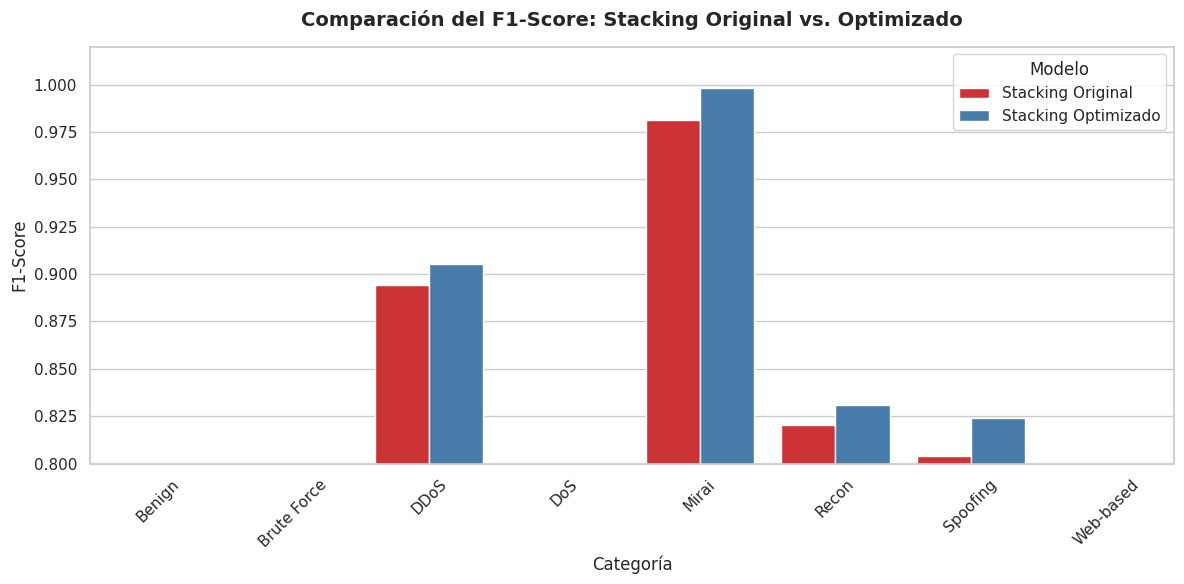

In [7]:
# Evaluar Stacking Optimizado
print("Evaluando Stacking Optimizado...")
preds_opt = stacking_opt.predict(X_test)
report_opt = classification_report(y_test, preds_opt, target_names=class_names, output_dict=True)
df_report_opt = pd.DataFrame(report_opt).transpose()

# Cargar reporte de Stacking original para comparar
try:
    df_report_orig = pd.read_csv("results/reporte_stacking.csv", index_col=0)
    
    # Crear DataFrame comparativo
    f1_comparison = pd.DataFrame({
        'Clase': class_names,
        'Stacking Original': [df_report_orig.loc[c, 'f1-score'] for c in class_names],
        'Stacking Optimizado': [df_report_opt.loc[c, 'f1-score'] for c in class_names]
    })
    
    f1_comparison['Mejora Absoluta'] = (f1_comparison['Stacking Optimizado'] - f1_comparison['Stacking Original']).round(4)
    print("\n--- Comparativa de F1-Score: Original vs. Optimizado ---")
    print(f1_comparison)
    
    # Guardar comparativa
    f1_comparison.to_csv("results/comparativa_tuning_stacking.csv", index=False)
    
    # Graficar comparación
    df_melted = pd.melt(f1_comparison.drop(columns=['Mejora Absoluta']), id_vars=['Clase'], var_name='Modelo', value_name='F1-Score')
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_melted, x='Clase', y='F1-Score', hue='Modelo', palette='Set1')
    plt.title("Comparación del F1-Score: Stacking Original vs. Optimizado", fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Categoría")
    plt.ylabel("F1-Score")
    plt.ylim(0.8, 1.02)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("results/figures/13_comparativa_tuning.png", dpi=300)
    plt.show()
except FileNotFoundError:
    print("No se encontró el reporte de Stacking original para comparar. Mostrando informe optimizado:")
    print(classification_report(y_test, preds_opt, target_names=class_names))